In [1]:
import os, sys, joblib
import numpy as np
import tensorflow as tf

# Make ../src importable when running from notebooks/
sys.path.append(os.path.abspath(".."))

from src.model import FiLM  # custom layer

MODEL_PATH = "../saved_model/ae_model.keras"
SCALER_PATH = "../saved_model/scaler.joblib"
META_PATH   = "../saved_model/detector_meta.joblib"

X_PATH = "../data/processed/X_all.npy"
C_PATH = "../data/processed/C_all.npy"

print("Paths set ✅")


2026-03-07 20:08:39.323097: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Paths set ✅


In [2]:
# FiLM is imported from src.model


In [3]:
# Load model with custom_objects (fixes FiLM error)
model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={"FiLM": FiLM},
    compile=False
)

scaler = joblib.load(SCALER_PATH)
detector_meta = joblib.load(META_PATH)

print("Loaded ✅")
print("Detector meta:", detector_meta)


Loaded ✅
Detector meta: {'topk': 19, 'threshold': 13.130608558654785}


2026-03-07 20:08:42.911081: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
/home/udara/Desktop/Research_model/project/venv/lib/python3.12/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'enc1_film', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/udara/Desktop/Research_model/project/venv/lib/python3.12/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'enc2_film', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite

In [4]:
def inject_anomalies(
    x, anomaly_ratio=0.08, seed=42,
    spike_mag=6.0, noise_std=0.8,
    seg_len=12, n_affect=2
):
    rng = np.random.default_rng(seed)
    x_anom = x.copy()
    n, T, F = x_anom.shape

    k = int(n * anomaly_ratio)
    idx = rng.choice(n, k, replace=False)

    y = np.zeros(n, dtype=np.int32)
    y[idx] = 1

    for i in idx:
        seg = min(seg_len, T)
        t0 = int(rng.integers(0, max(1, T - seg + 1)))
        feats = rng.choice(F, size=min(n_affect, F), replace=False)
        t_idx = np.arange(t0, t0 + seg)

        mode = rng.choice(["spike","drop","noise"])
        if mode == "spike":
            x_anom[i][np.ix_(t_idx, feats)] += spike_mag
        elif mode == "drop":
            x_anom[i][np.ix_(t_idx, feats)] -= spike_mag
        else:
            x_anom[i][np.ix_(t_idx, feats)] += rng.normal(
                0, noise_std, size=(len(t_idx), len(feats))
            )

    return x_anom, y

In [5]:
# =========================
# FULL EVALUATION BLOCK (SAFE ORDER)
# =========================
import numpy as np
import joblib
from sklearn.metrics import (
    precision_recall_curve,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# ----- Load model artifacts -----
scaler = joblib.load("../saved_model/scaler.joblib")
ctx_scaler = joblib.load("../saved_model/ctx_scaler.joblib")

# ----- Load data -----
X = np.load(X_PATH, allow_pickle=False)
C = np.load(C_PATH, allow_pickle=False)

print("Raw shapes:", X.shape, C.shape)

# ----- Subset -----
N_CLEAN = min(5000, len(X))
X_clean = X[:N_CLEAN].copy()
C_clean = C[:N_CLEAN].copy()

# ----- Fix NaNs -----
if np.isnan(X_clean).mean() > 0:
    X_clean = np.nan_to_num(X_clean, nan=0.0)

# ----- Apply X scaler -----
def apply_scaler(sc, X_in):
    N, T, F = X_in.shape
    X2 = sc.transform(X_in.reshape(N*T, F))
    return X2.reshape(N, T, F).astype(np.float32)

X_clean = apply_scaler(scaler, X_clean)

# ----- Apply context scaler -----
C_clean = ctx_scaler.transform(C_clean).astype(np.float32)

print("Scaled shapes:", X_clean.shape, C_clean.shape)

# ----- Inject synthetic anomalies (if not already) -----
# assuming you already have inject_anomalies()
X_test, y_true = inject_anomalies(X_clean, anomaly_ratio=0.08, seed=42)

# ----- Predict -----
X_test_pred = model.predict([X_test, C_clean], verbose=0)

def topk_score(x_true, x_pred, k):
    err = (x_true - x_pred) ** 2
    flat = err.reshape(len(err), -1)
    k = min(k, flat.shape[1])
    part = np.partition(flat, -k, axis=1)[:, -k:]
    return np.mean(part, axis=1)

WINDOW_SIZE = X_test.shape[1]
N_FEATURES  = X_test.shape[2]
TOPK = max(10, int(0.10 * (WINDOW_SIZE * N_FEATURES)))

test_scores = topk_score(X_test, X_test_pred, TOPK)

# ----- PR threshold -----
prec, rec, thr = precision_recall_curve(y_true, test_scores)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
best_i = np.argmax(f1)
best_thr = thr[max(0, best_i - 1)] if len(thr) > 0 else float(np.percentile(test_scores, 95))

print("TOPK:", TOPK)
print("Best threshold:", best_thr)
print("Best Precision:", float(prec[best_i]))
print("Best Recall   :", float(rec[best_i]))
print("Best F1       :", float(f1[best_i]))

# ----- Final metrics -----
y_hat = (test_scores >= best_thr).astype(int)

p, r, f1_final, _ = precision_recall_fscore_support(
    y_true, y_hat, average="binary", zero_division=0
)
cm = confusion_matrix(y_true, y_hat)

print("\n✅ FINAL RESULTS")
print("Precision:", float(p))
print("Recall   :", float(r))
print("F1       :", float(f1_final))
print("PR-AUC   :", float(average_precision_score(y_true, test_scores)))
print("ROC-AUC  :", float(roc_auc_score(y_true, test_scores)))
print("Confusion Matrix:\n", cm)

Raw shapes: (772049, 24, 8) (772049, 5)
Scaled shapes: (5000, 24, 8) (5000, 5)
TOPK: 19
Best threshold: 9.435295
Best Precision: 0.4171974522292994
Best Recall   : 0.655
Best F1       : 0.5097276264586685

✅ FINAL RESULTS
Precision: 0.4165341812400636
Recall   : 0.655
F1       : 0.5092322643343051
PR-AUC   : 0.28039956980312125
ROC-AUC  : 0.8487266304347826
Confusion Matrix:
 [[4233  367]
 [ 138  262]]


In [6]:
def topk_score(x_true: np.ndarray, x_pred: np.ndarray, k: int) -> np.ndarray:
    err = (x_true - x_pred) ** 2
    flat = err.reshape(len(err), -1)
    k = min(k, flat.shape[1])
    part = np.partition(flat, -k, axis=1)[:, -k:]
    return np.mean(part, axis=1)

In [7]:
from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

TOPK = int(detector_meta.get("topk", 50))
THRESH = float(detector_meta.get("threshold", 0.0))

X_test, y_true = inject_anomalies(
    X_clean,
    anomaly_ratio=0.08,
    seed=42
)

# predict
X_pred = model.predict([X_test, C_clean], verbose=0)

scores = topk_score(X_test, X_pred, TOPK)
y_hat = (scores >= THRESH).astype(int)

p, r, f1, _ = precision_recall_fscore_support(y_true, y_hat, average="binary", zero_division=0)
cm = confusion_matrix(y_true, y_hat)

pr_auc = average_precision_score(y_true, scores)
roc_auc = roc_auc_score(y_true, scores)

print("✅ RESULTS")
print("Precision:", float(p))
print("Recall   :", float(r))
print("F1       :", float(f1))
print("PR-AUC   :", float(pr_auc))
print("ROC-AUC  :", float(roc_auc))
print("Confusion Matrix:\n", cm)

✅ RESULTS
Precision: 0.3836477987421384
Recall   : 0.4575
F1       : 0.41733181299885974
PR-AUC   : 0.28039956980312125
ROC-AUC  : 0.8487266304347826
Confusion Matrix:
 [[4306  294]
 [ 217  183]]


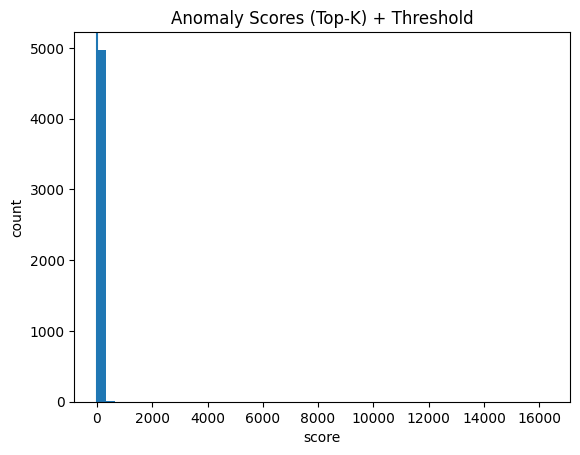

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(scores, bins=50)
plt.axvline(THRESH)
plt.title("Anomaly Scores (Top-K) + Threshold")
plt.xlabel("score")
plt.ylabel("count")
plt.show()